# D6 stage B: compute a regular inner profile
The question is whether a radial coefficient solver reproduces the paper's leading inner balances for declared analytic axis data. These inputs validate a local method; they are not the joined paper profile.

The [article](../../writing/d6_inner_profile/article.html) explains why this is needed before the first full correction. The [source notes](../../writing/d6_inner_profile/source-notes.md) specify the equations and checks. Radial degree here is not the correction index in the expansion in powers of q.

In [1]:
from pathlib import Path
import csv
import json
import mpmath as mp
from IPython.display import display, Image, Markdown
from nscomp.inner import AxisData, inner_series
from nscomp.d6b import load_parameters, generate, axis_values, STUDY, WRITING

p = load_parameters()
summary = generate()
print(json.dumps(p, indent=2))

{
  "study": "D6 stage B: leading inner equations with explicit validation axis data",
  "axis_data": {
    "h": 1e-06,
    "offset_j": 0.02,
    "regularization_sigma": 0.2,
    "radial_scale_Lambda": 512.0,
    "amplitude_C": 10000.0,
    "pressure_magnitude": 100.0
  },
  "axis_pressure": "Pi0(eta)=-100/(1+eta^2)^2; analytic test datum, not trace of an assembled outer profile",
  "qualification": "Full hierarchy and joining conditions not satisfied or certified; B.2 is explicitly checked and fails for these validation data",
  "eta_centers": [
    -0.6,
    0.0,
    0.05,
    0.2
  ],
  "maximum_Y": 4.1,
  "radial_samples": 61,
  "radial_degree": 22,
  "decimal_digits": 80,
  "reference_degree": 24,
  "degree_scan": {
    "eta": 0.2,
    "Y": 4.1,
    "degrees": [
      4,
      6,
      8,
      10,
      12,
      14,
      16,
      18,
      20,
      22
    ]
  },
  "lambda_scan": {
    "eta": 0.2,
    "Y": 1.0,
    "values": [
      128,
      256,
      512,
      1024,
     

## Evaluate the coupled profile
The first calculation retains the pressure increment separately. Its axis value can be much larger than its radial variation. All quantities are dimensionless.

Phi: 0.566186523718766501
U: 1.03351331856748859
F: 7.54400005629695176e-82
Pi: -92.4556213017751479
pressure_increment: 4.27691854711143955e-165
V0_over_X: -3.99313192738714609
angular_relative: 1.66969212771550379e-29
axial_relative: 6.39465626985589803e-45
pressure_relative: 3.83463795959319733e-24


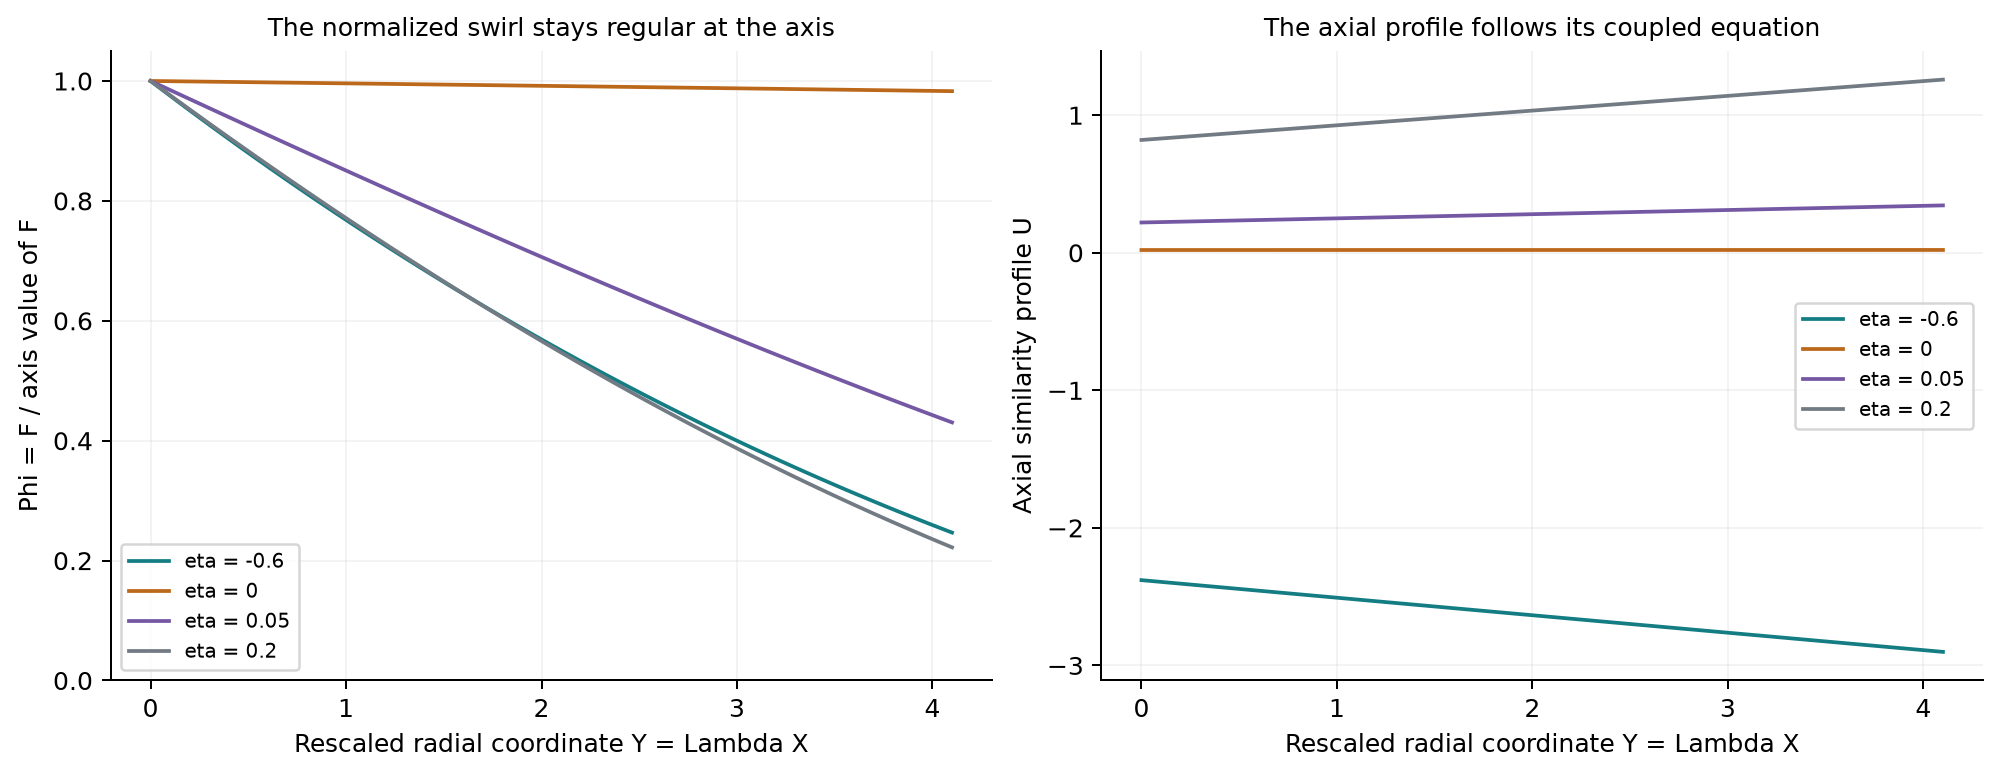

In [2]:
data = AxisData(**p["axis_data"])
series = inner_series(data, eta_center=0.2,
                      order=p["radial_degree"], digits=p["decimal_digits"])
v = series.evaluate(Y=2)
for name in ("Phi", "U", "F", "Pi", "pressure_increment", "V0_over_X",
             "angular_relative", "axial_relative", "pressure_relative"):
    print(f"{name}: {mp.nstr(v[name], 18)}")
display(Image(filename=str(WRITING / "figures/01_regular_inner_profiles.png")))

## Increase radial degree
The reference uses degree 24. It supplies a numerical comparison, not a rigorous error enclosure. Equation defects use their actual term magnitudes without replacing tiny denominators by a fixed floor.

degree   angular defect   axial defect     pressure defect
     4   6.920e-03        1.442e-06        3.471e-01
     6   1.747e-04        3.773e-10        1.750e-02
     8   7.568e-06        1.343e-13        2.315e-03
    10   1.130e-07        9.588e-17        9.192e-05
    12   9.659e-10        1.563e-20        2.156e-06
    14   5.467e-12        8.148e-24        3.477e-08
    16   2.205e-14        4.023e-28        4.155e-10
    18   6.608e-17        6.695e-31        3.851e-12
    20   1.509e-19        2.561e-35        2.857e-14
    22   2.649e-22        4.565e-38        1.739e-16


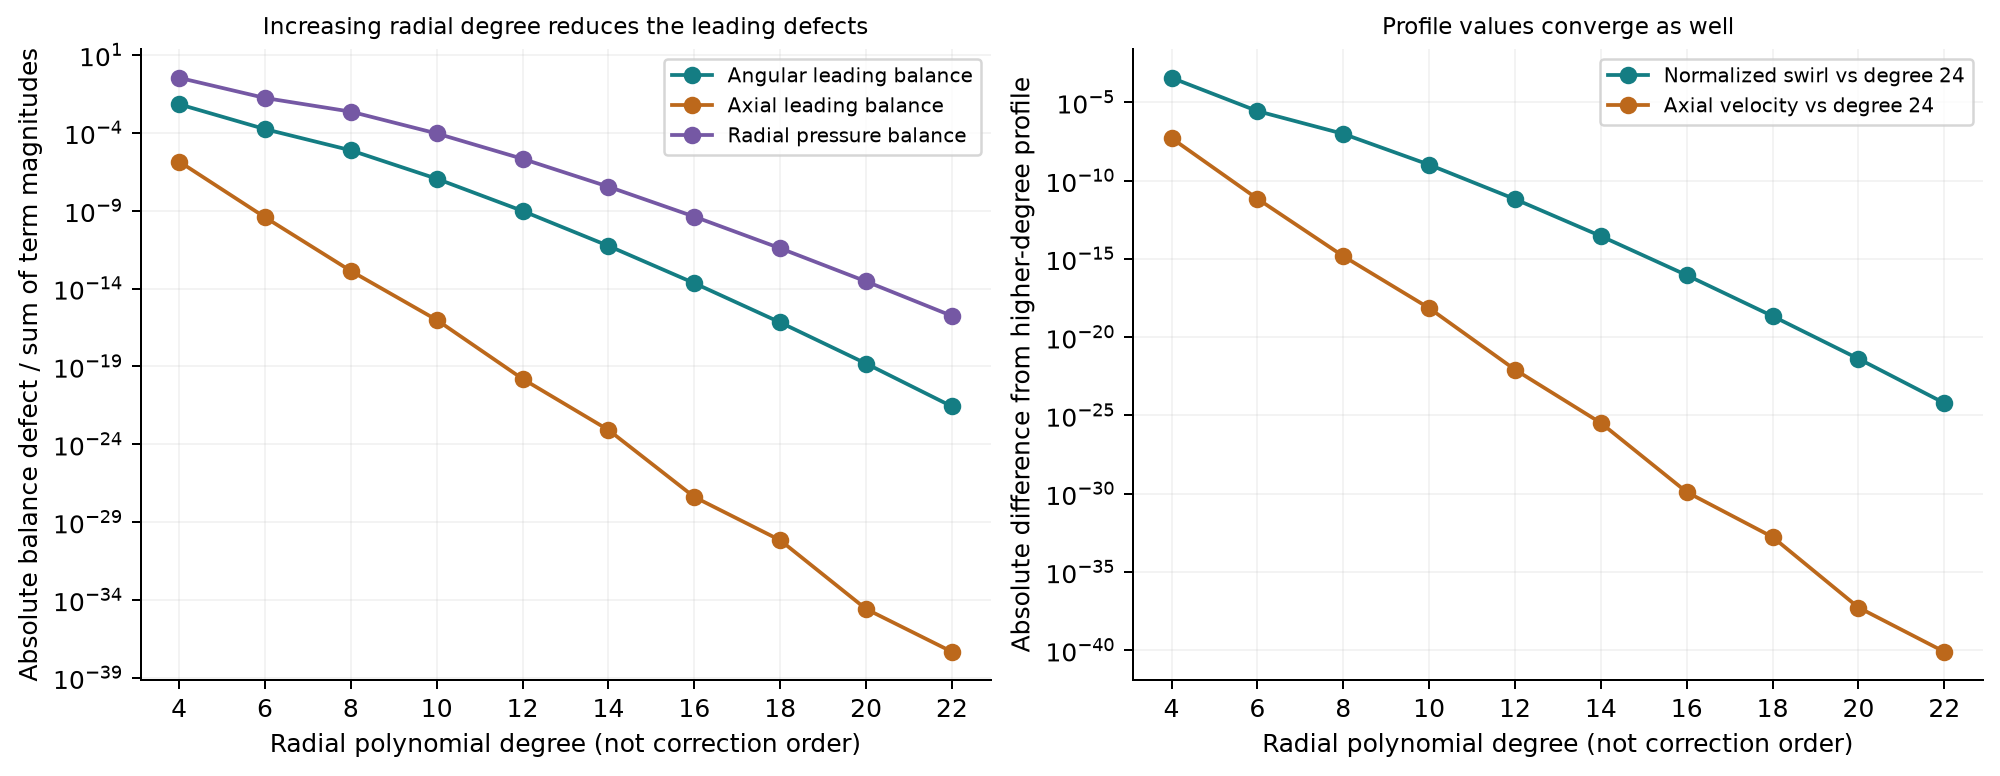

In [3]:
def read_rows(name):
    with (STUDY / "data" / name).open(encoding="utf-8", newline="") as stream:
        return list(csv.DictReader(stream))

print("degree   angular defect   axial defect     pressure defect")
for row in read_rows("degree_convergence.csv"):
    print(f'{int(row["radial_degree"]):6d}   '
          f'{float(row["angular_relative"]):.3e}        '
          f'{float(row["axial_relative"]):.3e}        '
          f'{float(row["pressure_relative"]):.3e}')
display(Image(filename=str(WRITING / "figures/02_radial_degree_convergence.png")))

## Compare with the source's large-Lambda expressions
At the selected point, the swirl difference decreases approximately as 1/Lambda. Including the first axial comparison term leaves a difference of order 1/Lambda squared. The complete parameter hierarchy and uniform estimates remain unverified.

Lambda   swirl difference   axial difference
   128   3.561310e-02       1.910962e-03
   256   1.783830e-02       4.633746e-04
   512   8.926125e-03       1.140421e-04
  1024   4.464686e-03       2.828501e-05
  2048   2.232734e-03       7.043043e-06


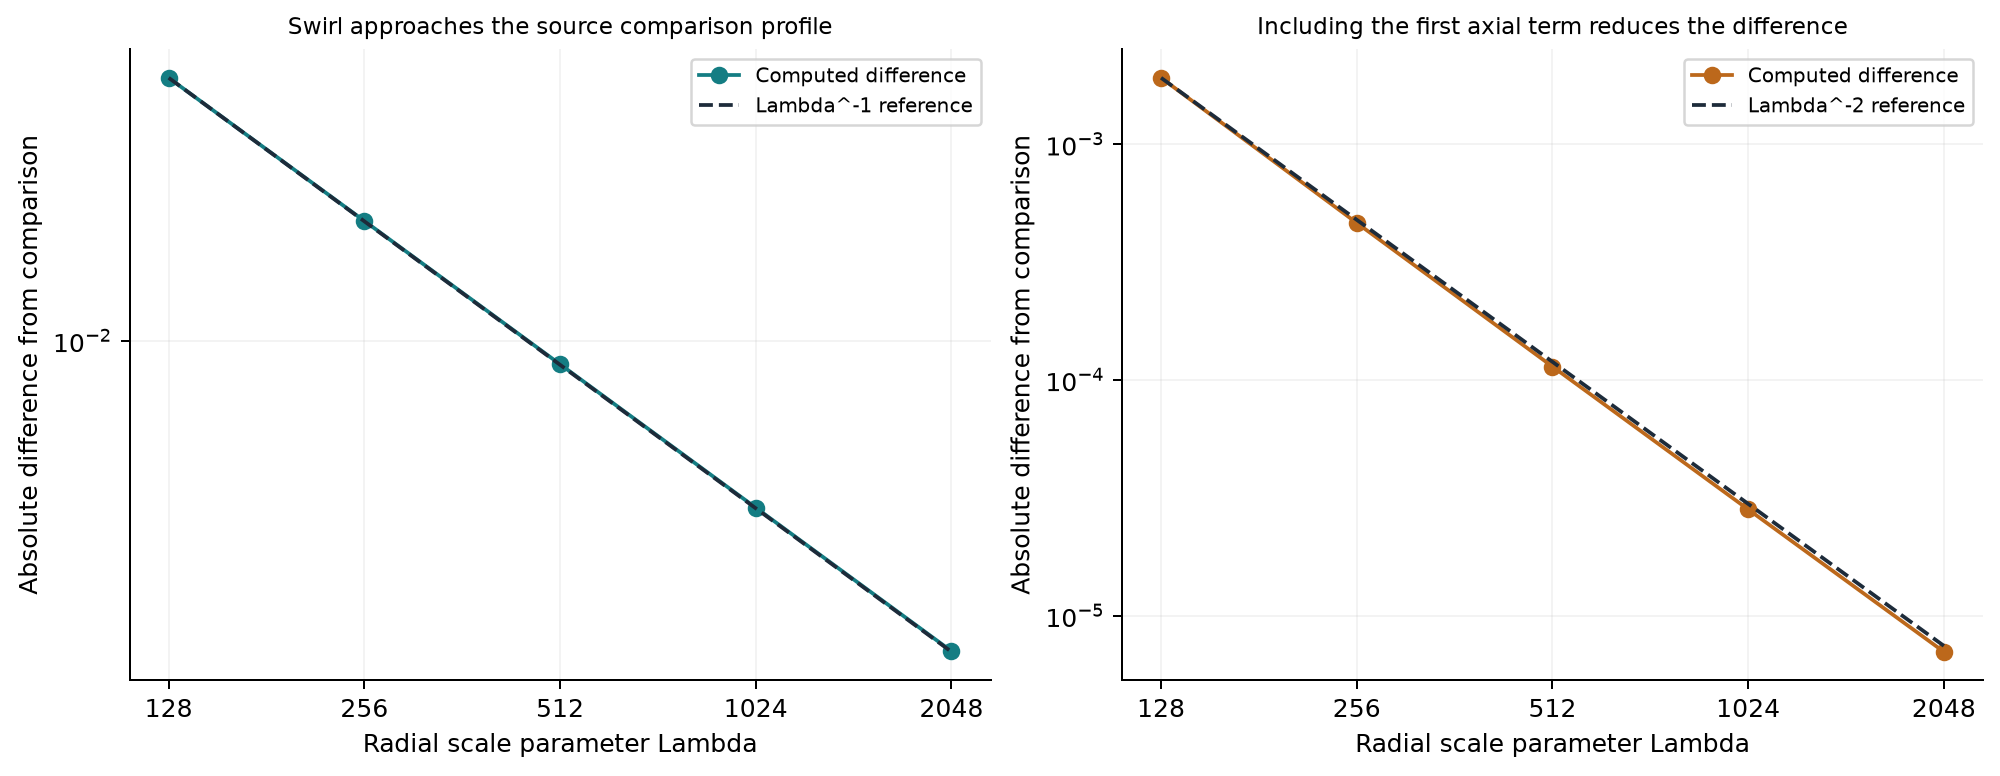

In [4]:
print("Lambda   swirl difference   axial difference")
for row in read_rows("large_lambda_comparison.csv"):
    print(f'{float(row["Lambda"]):6.0f}   '
          f'{float(row["Phi_comparison_error"]):.6e}       '
          f'{float(row["U_comparison_error"]):.6e}')
display(Image(filename=str(WRITING / "figures/03_large_lambda_comparison.png")))

## Check pressure storage and a joining requirement
The pressure-storage table compares a directly stored radial increment with subtraction of two total pressures. Lost increments are not zero physical gradients.
Condition B.2 requires chi>0.99 near zeros of Z_star. The present data explicitly fail it.

In [5]:
for row in read_rows("pressure_storage.csv"):
    print(f'eta={row["eta"]}: separate increment='
          f'{row["separate_increment_decimal"]}; recovered='
          f'{row["increment_recovered_from_total_decimal"]}; '
          f'relative loss={float(row["relative_increment_loss"]):.3g}')
print("Z_star zero:", summary["eta_of_validation_Z_zero"])
print("chi there:", summary["chi_at_validation_Z_zero"])
print("B.2 satisfied:", summary["condition_B2_satisfied"])
print("Joined profile:", summary["joined_inner_annular_profile"])

eta=-0.6: separate increment=2.165779110022155232275645e-285; recovered=0.0; relative loss=1
eta=0.0: separate increment=3.875039476097118303751231e-11; recovered=3.875039476097118303751231e-11; relative loss=1.27e-70
eta=0.05: separate increment=4.58776714531937010532749e-56; recovered=4.587767145319370105327492e-56; relative loss=3.38e-25
eta=0.2: separate increment=4.276918547111439553963639e-165; recovered=0.0; relative loss=1
Z_star zero: -0.00014516132444900473
chi there: 0.009270691436685793
B.2 satisfied: False
Joined profile: False


## Try a local alternative
This last cell changes only the evaluation point and radial degree. It does not alter the saved baseline. More extreme parameters or large eta offsets require renewed convergence and overlap checks.

Eight scientific checks run in the build, including independently centered expansions, precision refinement, and physical-coordinate finite differences for divergence and leading momentum. The full corrected Navier-Stokes residual remains outside this study.

In [6]:
alternative = inner_series(data, eta_center=0.05, order=12, digits=60)
for Y in (0, 0.5, 1):
    result = alternative.evaluate(Y)
    print("Y =", Y,
          "Phi =", mp.nstr(result["Phi"], 12),
          "U =", mp.nstr(result["U"], 12),
          "largest leading defect =", mp.nstr(max(
              result[key] for key in
              ("angular_relative", "axial_relative", "pressure_relative")), 5))
display(Markdown("Next dependency: prepared outer pressure and source-consistent axis data, "
                 "then annular continuation and moment matching; see the "
                 "[D6 implementation ledger](../../writing/d6_moment_correction/implementation-ledger.md)."))

Y = 0 Phi = 1.0 U = 0.22 largest leading defect = 5.3289e-62
Y = 0.5 Phi = 0.924799266291 U = 0.235068616508 largest leading defect = 1.0317e-20
Y = 1 Phi = 0.850624126408 U = 0.250160979685 largest leading defect = 4.5409e-17


Next dependency: prepared outer pressure and source-consistent axis data, then annular continuation and moment matching; see the [D6 implementation ledger](../../writing/d6_moment_correction/implementation-ledger.md).